In [420]:

import pandas as pd
import seaborn
import seaborn as sns
import xgboost
from catboost import CatBoostRegressor

from xgboost import XGBRegressor
from sklearn.preprocessing import OneHotEncoder,StandardScaler,PolynomialFeatures
from sklearn.model_selection import train_test_split,cross_val_score,KFold
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error,r2_score,root_mean_squared_error
import xgboost as xgb
import matplotlib.pyplot as plt
import lightgbm
from sklearn.linear_model import LinearRegression,Ridge,Lasso
import optuna
from sklearn.model_selection import cross_val_score,cross_validate,cross_val_predict
from sklearn.ensemble import IsolationForest


In [464]:
def load_data():
    X = pd.read_csv("StudentPerformanceFactors.csv")

    #X=X.dropna().reset_index(drop=True)


    X["outlier"] = np.where(X["Exam_Score"]>78,1,0)
    X = X[X["outlier"]!=1].reset_index()
    X.drop(columns=["outlier"],inplace=True)
    y = X["Exam_Score"]
    X.drop(columns=["Exam_Score"], inplace=True)






    return X,y
X,y = load_data()


In [ ]:
X,y=load_data()
fig,axs = plt.subplots(2,1)
sns.histplot(y,ax=axs[0])
sns.histplot(np.log(y),ax=axs[1])



R2 Score: 0.9905458676204357


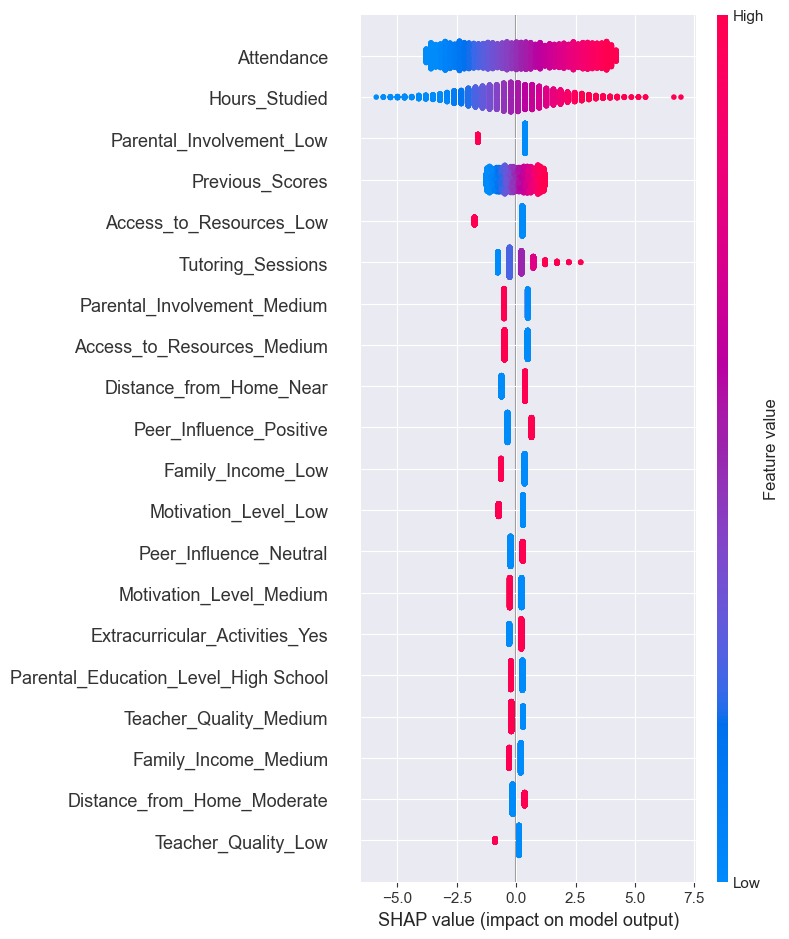

,feature,coef
0,index,-0.0051660220
1,Hours_Studied,1.7830576553
2,Attendance,2.3057151587
3,Sleep_Hours,0.0195464968
4,Previous_Scores,0.7141827350
5,Tutoring_Sessions,0.6134640796
6,Physical_Activity,0.2408233004
7,Parental_Involvement_Low,-1.9850700901
8,Parental_Involvement_Medium,-0.9978185945
9,Access_to_Resources_Low,-2.0083219148


In [474]:
import shap
X,y=load_data()
#y = np.log(y)
pd.options.display.float_format = '{:.10f}'.format

categorical_columns = X.select_dtypes(include="object").columns.tolist()
numeric = X.select_dtypes(exclude="object").columns.tolist()
encoder = OneHotEncoder(sparse_output=False,drop="first")
encoded = encoder.fit_transform(X[categorical_columns])
X.drop(columns=categorical_columns,inplace=True)
encoded_names = encoder.get_feature_names_out()
X = pd.concat(
    [X, pd.DataFrame(encoded, columns=encoded_names, index=X.index)],
    axis=1
)
scaler = StandardScaler()
X[numeric] = scaler.fit_transform(X[numeric])

X.columns = X.columns.astype(str)
X,X_test,y,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
lm = LinearRegression()
lm.fit(X,y)
preds = lm.predict(X_test)
r2 = r2_score(y_test,preds)
print(f'R2 Score: {r2}')
coefs = pd.DataFrame({"feature": X.columns, "coef": lm.coef_})

explainer = shap.LinearExplainer(lm, X)
shap_values = explainer(X)
shap.summary_plot(shap_values)

coefs

In [463]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold
import numpy as np
X,y = load_data()
#y = np.log(y)
categorical_columns = X.select_dtypes(include=object).columns.tolist()
numerical_columns = X.select_dtypes(exclude=object).columns.tolist()
transformer = ColumnTransformer([
    ("onehot",OneHotEncoder(sparse_output=False,drop="first"),categorical_columns),
     ("scaler",StandardScaler(),numerical_columns)
])
pipeline = Pipeline([
    ("preprocess",transformer),
    ("model",LinearRegression())
])

print(f'Linear CV: {np.mean(cross_val_score(pipeline,X,y))} ')

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = []

for train_idx, val_idx in kf.split(X):
    X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_train, y_val = y[train_idx].copy(), y[val_idx].copy()

    onehot = OneHotEncoder(sparse_output=False,drop="first")
    scaler =StandardScaler()

    X_train_encoded = onehot.fit_transform(X_train[categorical_columns])
    X_val_encoded = onehot.transform(X_val[categorical_columns])



    X_train[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])
    X_val[numerical_columns] = scaler.transform(X_val[numerical_columns])
    X_train  = pd.concat([X_train[numerical_columns],pd.DataFrame(X_train_encoded,index = X_train.index)],axis=1)
    X_val = pd.concat([X_val[numerical_columns],pd.DataFrame(X_val_encoded,index = X_val.index)],axis=1)


    model = XGBRegressor(random_state=42,early_stopping_rounds=50,learning_rate=0.2,max_depth=3,n_estimators=1000)
    model.fit(X_train,y_train,eval_set=[(X_val,y_val)],verbose=False)
    preds = model.predict(X_val)
    r2 = r2_score(y_val,preds)
    scores.append(r2)

np.mean(scores)



Linear CV: 0.9876107641630736 


np.float64(0.9801787734031677)

<Axes: xlabel='Sleep_Hours', ylabel='Exam_Score'>

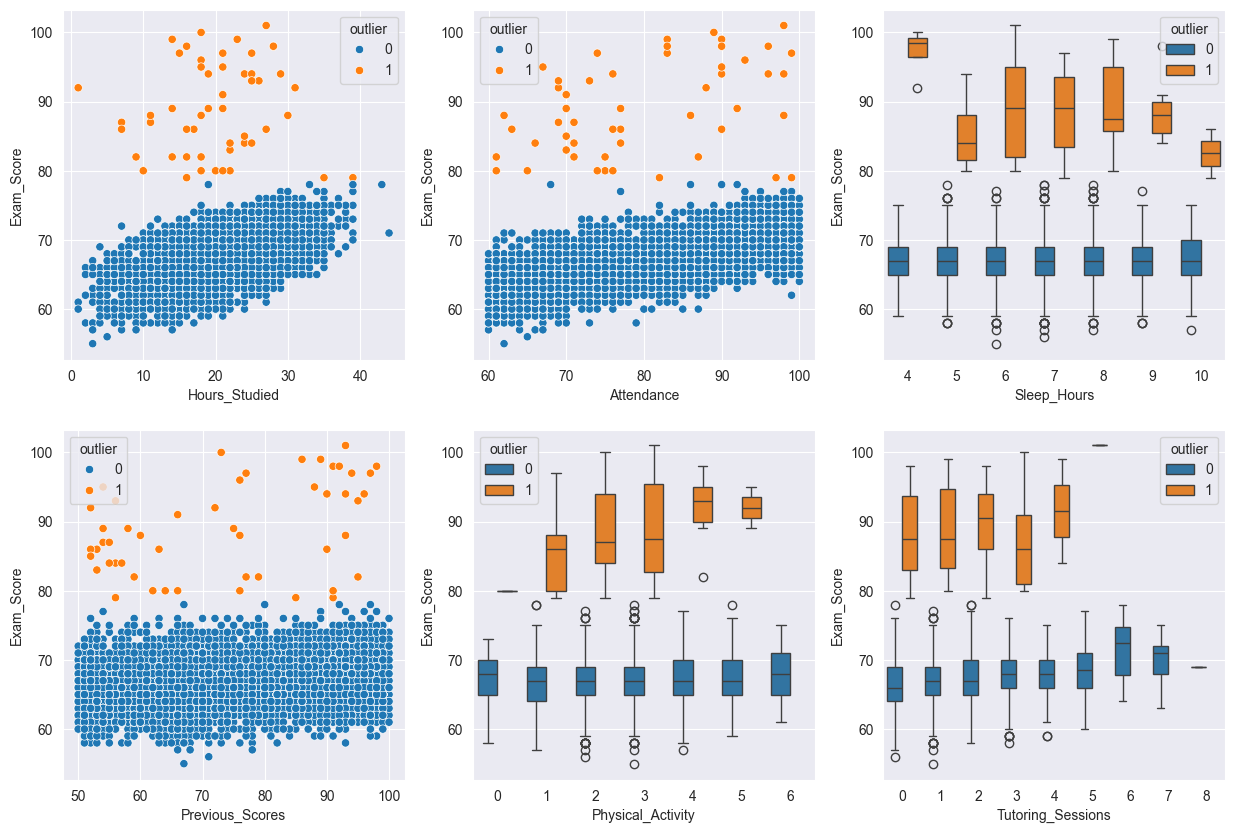

In [413]:
#students = pd.read_csv("StudentPerformanceFactors.csv")
students,exam_score = load_data()
students["Exam_Score"] = exam_score
fig,axs = plt.subplots(ncols=3,nrows=2,figsize=(15,10))
sns.scatterplot(data=students,x="Hours_Studied",y="Exam_Score",ax=axs[0,0],hue="outlier")
sns.scatterplot(data=students,x="Attendance",y="Exam_Score",ax=axs[0,1],hue="outlier")
sns.scatterplot(data=students,x="Previous_Scores",y="Exam_Score",ax=axs[1,0],hue="outlier")
sns.boxplot(data=students,x="Physical_Activity",y="Exam_Score",ax=axs[1,1],hue="outlier")
sns.boxplot(data=students,x="Tutoring_Sessions",y="Exam_Score",ax=axs[1,2],hue="outlier")
sns.boxplot(data=students,x="Sleep_Hours",y="Exam_Score",ax=axs[0,2],hue="outlier")

In [270]:
students

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,outlier,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,...,Medium,Public,Positive,3,No,High School,Near,Male,1,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,...,Medium,Public,Negative,4,No,College,Moderate,Female,1,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,...,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,1,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,...,Medium,Public,Negative,4,No,High School,Moderate,Male,1,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,...,High,Public,Neutral,4,No,College,Near,Female,1,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,...,Medium,Public,Positive,2,No,High School,Near,Female,1,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,...,High,Public,Positive,2,No,High School,Near,Female,1,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,...,Medium,Public,Negative,2,No,Postgraduate,Near,Female,1,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,...,Medium,Private,Positive,3,No,High School,Far,Female,1,68


In [ ]:
X,y = load_data()
y=np.log(y)
categorical_columns = X.select_dtypes(include="object").columns.tolist()
X[categorical_columns] = X[categorical_columns].astype("category")
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42,shuffle=True)
X_test,X_validation,y_test,y_validation = train_test_split(X_test,y_test,test_size=0.5,random_state=42)
model = XGBRegressor(n_estimators=1500,learning_rate=0.02,enable_categorical=True,reg_lambda=10,random_state=42,early_stopping_rounds = 50)
model.fit(X_train,y_train,eval_set=[(X_validation,y_validation)],verbose=100)
preds = model.predict(X_test)

resid = preds-y_test
r2 = r2_score(y_test,preds)


print(f'R2 full {r2} ')

resid = y_test-preds
xgboost.plot_importance(model)
#sns.scatterplot(x=preds,y=y_test,hue  =resid)

## CAT

In [ ]:
X,y = load_data()
y=np.log(y)
categorical_columns = X.select_dtypes(include=['object']).columns.tolist()
X[categorical_columns] = X[categorical_columns].fillna("NaN")
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42,shuffle=True)
X_test,X_validation,y_test,y_validation = train_test_split(X_test,y_test,test_size=0.5,random_state=42)
model_cat =CatBoostRegressor(use_best_model=True,early_stopping_rounds=50)
model_cat.fit(X_train,y_train,cat_features=categorical_columns,eval_set=[(X_validation,y_validation)],verbose=100)
preds = model_cat.predict(X_test)
r2_test=r2_score(y_test,preds)
preds_full =model_cat.predict(X)
r2_full = r2_score(y,preds_full)
rmse = root_mean_squared_error(y_test,preds)
rmse_full = root_mean_squared_error(y,preds_full)
print(f'R2 test {r2_test} ')
print(f'R2 full {r2_full} ')
print(f'RMSE test {rmse} ')
print(f'RMSE full {rmse_full} ')


## LGBM

In [ ]:

X,y =  load_data()
y=np.log(y)
categorical_columns = X.select_dtypes(include=['object']).columns.tolist()
X[categorical_columns] = X[categorical_columns].astype("category")

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42,shuffle=True)
X_test,X_validation,y_test,y_validation = train_test_split(X_test,y_test,test_size=0.5,random_state=42)
params = {'learning_rate': 0.0970688720107848, 'num_leaves': 20, 'feature_fraction': 0.7206082609076269, 'max_depth': 4}
model = lightgbm.LGBMRegressor(**params,random_state=42,early_stopping_rounds = 50,n_estimators=5000)
model.fit(X_train,y_train,categorical_feature=categorical_columns,eval_set=[(X_validation,y_validation)])
preds = model.predict(X_test)
preds_full = model.predict(X)
r2 = r2_score(y_test,preds)
r2_full = r2_score(y,preds_full)
rmse = root_mean_squared_error(y_test,preds)
rmse_full = root_mean_squared_error(y,preds_full)
print(f'R2 test {r2_test} ')
print(f'R2 full {r2_full} ')
print(f'RMSE test {rmse} ')
print(f'RMSE full {rmse_full} ')


In [ ]:
X,y = load_data()
X=X.dropna()
X

In [ ]:
X,y =  load_data()
categorical_columns = X.select_dtypes(include=['object']).columns.tolist()
X[categorical_columns] = X[categorical_columns].fillna("NaN")
X[categorical_columns] = X[categorical_columns].astype("category")

paramsXGB = {
        "n_estimators":3000,
        "max_depth":3,
        "gamma":1.4,
        "subsample":0.8,
    "learning_rate":0.01
    }
params_lgbm = {'learning_rate': 0.0970688720107848, 'num_leaves': 20, 'feature_fraction': 0.7206082609076269, 'max_depth': 4}
X,X_val,y,y_val = train_test_split(X,y,test_size=0.2,random_state=42,shuffle=True)
xgb = XGBRegressor(**paramsXGB,random_state=42,enable_categorical=True,early_stopping_rounds=50)
cat = CatBoostRegressor(random_state=42,use_best_model=True,early_stopping_rounds=50)
lgbm = lightgbm.LGBMRegressor(**params_lgbm,random_state=42,use_best_model=True,early_stopping_rounds=50,verbosity=-1)
print(np.mean(cross_validate(cat,X,y,params={"cat_features": categorical_columns,"eval_set":[(X_val,y_val)],"verbose":500})["test_score"]))
print(np.mean(cross_validate(xgb,X,y,params={"eval_set":[(X_val,y_val)],"verbose":0})["test_score"]))
print(np.mean(cross_validate(lgbm,X,y,params={"eval_set":[(X_val,y_val)]})["test_score"]))